In [ ]:
# Cell 1: Setup and Model Loading
!pip install open_clip_torch > /dev/null

import os
import numpy as np
import pandas as pd
import torch
import cv2
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, accuracy_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import open_clip
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
base_path = "/content/drive/MyDrive/MrNet-v1/MRNet-v1.0"
axial_dir = base_path + "/merged_data/axial"
coronal_dir  = base_path + "/merged_data/coronal"
sagittal_dir = base_path + "/merged_data/sagittal"
val_df = pd.read_csv(base_path + "/val_split.csv")

# Load BioMedCLIP
print("Loading BioMedCLIP...")
model_name = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
model, _, preprocess = open_clip.create_model_and_transforms(model_name)
model = model.to(device)
model.eval() # Zero-shot requires eval mode
tokenizer = open_clip.get_tokenizer(model_name)
print("Loaded successfully!")

Mounted at /content/drive
Using device: cuda
Loading BioMedCLIP...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Loaded successfully!


In [ ]:
# Cell 2: Prompt Ensembling Logic
def get_ensembled_text_features(plane_name):
    """
    Creates multiple prompts per class, encodes them, and averages the embeddings.
    This provides a much more robust semantic target than a single sentence.
    """
    prompts_healthy = [
        f"A {plane_name} plane magnetic resonance imaging slice of a normal human knee with an intact anterior cruciate ligament.",
        f"A healthy knee MRI in {plane_name} view showing no ligament injury.",
        f"Normal intact ACL in a {plane_name} view MRI of the knee."
    ]

    prompts_tear = [
        f"A {plane_name} plane magnetic resonance imaging slice of a human knee showing an anterior cruciate ligament tear.",
        f"A knee MRI with a torn anterior cruciate ligament in {plane_name} view.",
        f"Ruptured ACL visible in a {plane_name} view MRI of the knee."
    ]

    with torch.no_grad():
        # Encode Healthy Prompts and Average them
        tok_healthy = tokenizer(prompts_healthy).to(device)
        feat_healthy = model.encode_text(tok_healthy).mean(dim=0, keepdim=True)

        # Encode Tear Prompts and Average them
        tok_tear = tokenizer(prompts_tear).to(device)
        feat_tear = model.encode_text(tok_tear).mean(dim=0, keepdim=True)

        # Combine into shape [2, embedding_dim]
        text_features = torch.cat([feat_healthy, feat_tear], dim=0)

        # Normalize the ensembled features (Standard CLIP practice)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    return text_features

In [ ]:
# Cell 3: Dataset with Proper MRI Intensity Normalization
def fix_slices(volume, target_slices=20):
    slices = volume.shape[0]
    if slices == target_slices: return volume
    if slices > target_slices:
        start = (slices - target_slices) // 2
        return volume[start:start + target_slices]
    else:
        pad = target_slices - slices
        return np.pad(volume, ((pad//2, pad - pad//2), (0, 0), (0, 0)), mode="constant")

class BioMedCLIP_MRNetDataset(Dataset):
    def __init__(self, df, plane_dir, preprocess_fn):
        self.df = df
        self.plane_dir = plane_dir
        self.preprocess = preprocess_fn

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        patient_id = str(self.df.iloc[idx]["id"]).zfill(4)
        label = self.df.iloc[idx]["label"]

        vol = np.load(os.path.join(self.plane_dir, patient_id + ".npy"))
        vol = fix_slices(vol)

        # FIX #2: Z-Score Volume Normalization (Centers data around 0)
        vol = (vol - vol.mean()) / (vol.std() + 1e-6)

        processed_slices = []
        for i in range(vol.shape[0]):
            slice_img = cv2.resize(vol[i], (224, 224))

            # FIX #1: Min-Max Scaling per slice to preserve contrast
            slice_img = (slice_img - slice_img.min()) / (slice_img.max() - slice_img.min() + 1e-6)
            slice_img = (slice_img * 255).astype(np.uint8)

            # Stack to 3 channels (RGB required by ViT)
            slice_rgb = np.stack((slice_img,)*3, axis=-1)

            # BioMedCLIP Preprocessing
            img_pil = Image.fromarray(slice_rgb)
            img_tensor = self.preprocess(img_pil)
            processed_slices.append(img_tensor)

        return torch.stack(processed_slices), torch.tensor(label, dtype=torch.float32), patient_id

In [ ]:
# Cell 4: Zero-Shot Inference with Top-K Aggregation
def extract_plane_probabilities(plane_name, plane_dir):
    """
    Runs Zero-Shot on one plane and returns the probabilities for multi-plane fusion later.
    """
    print(f"Extracting features for {plane_name.upper()}...")
    text_features = get_ensembled_text_features(plane_name)

    dataset = BioMedCLIP_MRNetDataset(val_df, plane_dir, preprocess)
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=2)

    patient_probs = []
    labels = []
    suspicious_slices = {} # For explainability later

    with torch.no_grad():
        for imgs, lbl, p_id in loader:
            imgs = imgs.squeeze(0).to(device) # Shape [20, 3, 224, 224]
            lbl = lbl.item()
            p_id = p_id[0]

            # Get Image Embeddings
            image_features = model.encode_image(imgs)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            # Calculate Cosine Similarity
            logit_scale = model.logit_scale.exp()
            logits_per_image = logit_scale * image_features @ text_features.t()
            probs = logits_per_image.softmax(dim=-1)

            # Probability of Class 1 (Tear) for all 20 slices
            prob_tear_per_slice = probs[:, 1]

            # FIX #4: Top-K Aggregation (Much more medically stable than Max)
            topk_vals, topk_indices = torch.topk(prob_tear_per_slice, k=3)
            patient_prob_tear = torch.mean(topk_vals).item()

            # Store the absolute highest slice index for Explainability
            most_suspicious_idx = topk_indices[0].item()
            suspicious_slices[p_id] = most_suspicious_idx

            patient_probs.append(patient_prob_tear)
            labels.append(lbl)

    return np.array(patient_probs), np.array(labels), suspicious_slices

Extracting features for AXIAL...
Extracting features for CORONAL...
Extracting features for SAGITTAL...

ZERO-SHOT ENSEMBLE RESULTS (Axial + Coronal + Sagittal)
Optimal decision threshold found: 0.7758
Ensemble AUC:      0.5447
Ensemble Accuracy: 65.60%



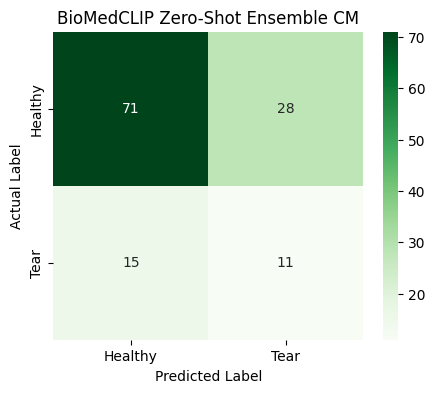

In [ ]:
# Cell 5: Execute and Fuse!
# 1. Gather probabilities for all planes independently
axial_probs, y_true, axial_explain = extract_plane_probabilities("axial", axial_dir)
coronal_probs, _, coronal_explain = extract_plane_probabilities("coronal", coronal_dir)
sagittal_probs, _, sagittal_explain = extract_plane_probabilities("sagittal", sagittal_dir)

# 2. HIGH IMPACT #1: Multi-Plane Fusion
# Average the probabilities across the 3 views
ensemble_probs = (axial_probs + coronal_probs + sagittal_probs) / 3.0

# 3. FIX #5: Find optimal threshold using Youden's J statistic
# CLIP outputs aren't perfectly calibrated, so 0.5 might not be the best cutoff
fpr, tpr, thresholds = roc_curve(y_true, ensemble_probs)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\n" + "="*50)
print("ZERO-SHOT ENSEMBLE RESULTS (Axial + Coronal + Sagittal)")
print("="*50)
print(f"Optimal decision threshold found: {optimal_threshold:.4f}")

# Calculate final metrics using the optimal threshold
final_preds = (ensemble_probs >= optimal_threshold).astype(int)
auc = roc_auc_score(y_true, ensemble_probs)
acc = accuracy_score(y_true, final_preds)

print(f"Ensemble AUC:      {auc:.4f}")
print(f"Ensemble Accuracy: {acc*100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_true, final_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Healthy', 'Tear'], yticklabels=['Healthy', 'Tear'])
plt.title(f"BioMedCLIP Zero-Shot Ensemble CM")
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

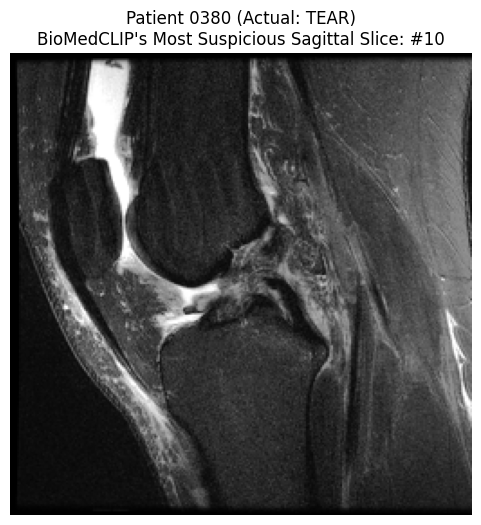

In [ ]:
# Cell 6: Explainability - Visualize the model's focus
def visualize_most_suspicious_slice(patient_idx=0, plane="sagittal"):
    """
    Loads a patient's volume and plots the exact slice that BioMedCLIP
    gave the highest probability of containing a tear.
    """
    patient_id = str(val_df.iloc[patient_idx]["id"]).zfill(4)
    true_label = val_df.iloc[patient_idx]["label"]

    # Get the dictionary of suspicious slices based on the chosen plane
    explain_dict = sagittal_explain if plane == "sagittal" else (coronal_explain if plane == "coronal" else axial_explain)
    target_slice_idx = explain_dict[patient_id]

    # Load raw volume to show the image
    plane_dir = sagittal_dir if plane == "sagittal" else (coronal_dir if plane == "coronal" else axial_dir)
    vol = np.load(os.path.join(plane_dir, patient_id + ".npy"))

    # We must apply fix_slices so the indexing matches what the model saw
    slices = vol.shape[0]
    if slices > 20: start = (slices - 20) // 2; vol = vol[start:start + 20]
    elif slices < 20: pad = 20 - slices; vol = np.pad(vol, ((pad//2, pad - pad//2), (0, 0), (0, 0)), mode="constant")

    img_to_show = vol[target_slice_idx]

    plt.figure(figsize=(6, 6))
    plt.imshow(img_to_show, cmap='gray')
    status = "TEAR" if true_label == 1 else "HEALTHY"
    plt.title(f"Patient {patient_id} (Actual: {status})\nBioMedCLIP's Most Suspicious {plane.capitalize()} Slice: #{target_slice_idx}")
    plt.axis('off')
    plt.show()

# Example: Show where the model looked for the first patient in the validation set on the sagittal plane
visualize_most_suspicious_slice(patient_idx=0, plane="sagittal")
# Feel free to change patient_idx to see other patients!